# Maritime Speed Prediction — Baseline Models

## Goal
Build and evaluate models predicting **SOG (Speed Over Ground)** as a function of environmental conditions. Then compare two scenarios: *baseline* (no rotor contribution) vs *with rotors*.

## Model hierarchy (per project spec)
| # | Model | Description |
|---|---|---|
| B1 | Constant mean | Predict the voyage mean SOG — naive baseline |
| B2 | Linear regression | `SOG = f(U_wind, H_s)` |
| M1 | XGBoost | `SOG = f(U_wind, H_s, α, currents, ...)` |

## Validation strategy
**Voyage-based split** — training and test sets contain different voyages. This prevents temporal leakage (the model never sees future observations from voyages it was trained on), which matches the real deployment scenario where we predict a new voyage.

## 0. Setup

In [1]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 10.1 MB/s  0:00:00eta 0:00:01

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

# Fix XGBoost OpenMP dependency on macOS
os.environ['LDFLAGS'] = '-L/opt/homebrew/opt/libomp/lib'
os.environ['CPPFLAGS'] = '-I/opt/homebrew/opt/libomp/include'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import RegularGridInterpolator
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

plt.style.use('seaborn-v0_8-darkgrid')

DATA_PATH = '../data/MasterSet_features.csv'
RESULTS_PATH = '../results/'

## 1. Load Data

In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=['Time'])
df = df.sort_values('Time').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Voyages: {df['Voyage_ID'].nunique()}")
print(f"Time range: {df['Time'].min()} → {df['Time'].max()}")
print(f"\nTarget (Speed_kn):")
print(df['Speed_kn'].describe().round(2))

Shape: (125160, 57)
Voyages: 528
Time range: 2023-02-02 00:06:00 → 2026-02-02 07:25:00

Target (Speed_kn):
count    125160.00
mean         11.52
std           2.15
min           5.00
25%          10.10
50%          11.70
75%          12.80
max          20.00
Name: Speed_kn, dtype: float64


## 2. Feature Selection and Voyage-Based Split

Features are grouped into:
- **Core** (spec base model): `True_Wind_Speed_ms`, `H_s`, `alpha_deg`
- **Extended**: add current vector, wave period, gusts

Split: sort voyages chronologically, use the last 20% as test set.

In [6]:
TARGET = 'Speed_kn'

# === BASELINE MODELS ===
# B1: Constant mean (no features needed)
# B2: Simple linear regression with core features only
FEATURES_BASE = ['True_Wind_Speed_ms', 'H_s', 'alpha_sin', 'alpha_cos']

# === EXTENDED MODEL (XGBoost) ===
# Core: spec features
# + Lag features: historical speed
# + Apparent wind: higher impact than true wind
# + Angle encodings: proper circular representation
# + Current effects: ocean conditions
# + Interactions: nonlinear relationships
FEATURES_EXT = [
    # Core spec features (encoded)
    'True_Wind_Speed_ms', 'H_s', 'alpha_sin', 'alpha_cos',
    'wind_speed_sq',
    
    # Lag features (no leakage — from observed trajectory)
    'Speed_kn_lag1', 'Speed_kn_lag2', 'Speed_kn_mean3',
    
    # Apparent wind (high impact)
    'Apparent_Wind_Speed_ms', 'app_alpha_sin', 'app_alpha_cos',
    'app_wind_speed_sq',
    
    # Course information (using raw degree for now, not encoded)
    'Course_deg',
    
    # Wave features
    'mwp', 'wave_period_sq', 'wave_wind_alignment',
    
    # Current effects
    'Current_Speed_ms', 'current_dir_sin', 'current_dir_cos',
    'current_along_course', 'current_cross_course',
    
    # Gust feature
    'fg10',
    
    # Interactions (physical relationships)
    'wind_x_angle_sin', 'wind_x_angle_cos',
    'app_wind_x_angle_sin', 'app_wind_x_angle_cos',
    'wind_x_wave', 'app_wind_x_wave',
    'current_x_course_help',
]

# Voyage-based chronological split: last 20% of voyages → test
voyage_order = (
    df.groupby('Voyage_ID')['Time'].min()
    .sort_values()
    .index.tolist()
)
split_idx = int(len(voyage_order) * 0.8)
train_voyages = set(voyage_order[:split_idx])
test_voyages  = set(voyage_order[split_idx:])

train_mask = df['Voyage_ID'].isin(train_voyages)
test_mask  = df['Voyage_ID'].isin(test_voyages)

df_train = df[train_mask].dropna(subset=FEATURES_EXT + [TARGET])
df_test  = df[test_mask].dropna(subset=FEATURES_EXT + [TARGET])

print(f"Train: {len(df_train):,} rows, {len(train_voyages)} voyages")
print(f"Test:  {len(df_test):,} rows, {len(test_voyages)} voyages")
print(f"Train time: {df_train['Time'].min().date()} → {df_train['Time'].max().date()}")
print(f"Test time:  {df_test['Time'].min().date()} → {df_test['Time'].max().date()}")
print(f"\nNo temporal leakage: {df_train['Time'].max() < df_test['Time'].min()}")
print(f"\nFeatures used in extended model (M1): {len(FEATURES_EXT)}")
print(f"Features used in baseline 2 (B2): {len(FEATURES_BASE)}")

Train: 88,346 rows, 422 voyages
Test:  35,758 rows, 106 voyages
Train time: 2023-02-02 → 2025-05-23
Test time:  2025-05-23 → 2026-02-02

No temporal leakage: True

Features used in extended model (M1): 29
Features used in baseline 2 (B2): 4


## 3. Baseline 1 — Constant Mean Speed

Predicts the training-set mean SOG for every test observation. Sets the floor for model performance.

In [7]:
y_train = df_train[TARGET].values
y_test  = df_test[TARGET].values

mean_speed = y_train.mean()
y_pred_b1  = np.full_like(y_test, mean_speed)

results = {}

def eval_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    within_1kn = np.mean(np.abs(y_pred - y_true) <= 1.0) * 100
    results[name] = dict(MAE=mae, RMSE=rmse, R2=r2, within_1kn=within_1kn)
    print(f"{name:30s}  MAE={mae:.3f} kn  RMSE={rmse:.3f} kn  R²={r2:.3f}  within±1kn={within_1kn:.1f}%")

eval_metrics(y_test, y_pred_b1, 'B1: Constant mean')
print(f"(mean speed = {mean_speed:.2f} kn)")

B1: Constant mean               MAE=1.388 kn  RMSE=1.893 kn  R²=-0.002  within±1kn=49.3%
(mean speed = 11.56 kn)


## 4. Baseline 2 — Linear Regression (wind + wave)

Per spec: simple linear regression with wind speed and wave height.

In [8]:
scaler_b2 = StandardScaler()
X_train_b2 = scaler_b2.fit_transform(df_train[FEATURES_BASE])
X_test_b2  = scaler_b2.transform(df_test[FEATURES_BASE])

lr = LinearRegression()
lr.fit(X_train_b2, y_train)
y_pred_b2 = lr.predict(X_test_b2)

eval_metrics(y_test, y_pred_b2, 'B2: Linear (wind+wave+α encoded)')

print("\n" + "="*60)
print("Linear regression coefficients (normalized features):")
print("="*60)
for feat, coef in zip(FEATURES_BASE, lr.coef_):
    print(f"  {feat:<35s}: {coef:+.6f}")
print(f"  {'intercept':<35s}: {lr.intercept_:+.6f}")
print(f"\nModel explains {results['B2: Linear (wind+wave+α encoded)']['R2']:.1%} of variance")

B2: Linear (wind+wave+α encoded)  MAE=1.377 kn  RMSE=1.860 kn  R²=0.034  within±1kn=49.5%

Linear regression coefficients (normalized features):
  True_Wind_Speed_ms                 : +0.233049
  H_s                                : -0.062356
  alpha_sin                          : -0.009911
  alpha_cos                          : -0.278299
  intercept                          : +11.560826

Model explains 3.4% of variance


## 5. Main Model — XGBoost (extended features)

In [9]:
scaler_xgb = StandardScaler()
X_train_xgb = scaler_xgb.fit_transform(df_train[FEATURES_EXT])
X_test_xgb  = scaler_xgb.transform(df_test[FEATURES_EXT])

model_xgb = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model_xgb.fit(X_train_xgb, y_train)
y_pred_xgb = model_xgb.predict(X_test_xgb)

eval_metrics(y_test, y_pred_xgb, 'M1: XGBoost (extended)')

M1: XGBoost (extended)          MAE=0.111 kn  RMSE=0.162 kn  R²=0.993  within±1kn=99.9%


## 6. Model Comparison

In [10]:
summary = pd.DataFrame(results).T.round(3)
summary.index.name = 'Model'
print(summary.to_string())

                                    MAE   RMSE     R2  within_1kn
Model                                                            
B1: Constant mean                 1.388  1.893 -0.002      49.251
B2: Linear (wind+wave+α encoded)  1.377  1.860  0.034      49.474
M1: XGBoost (extended)            0.111  0.162  0.993      99.880


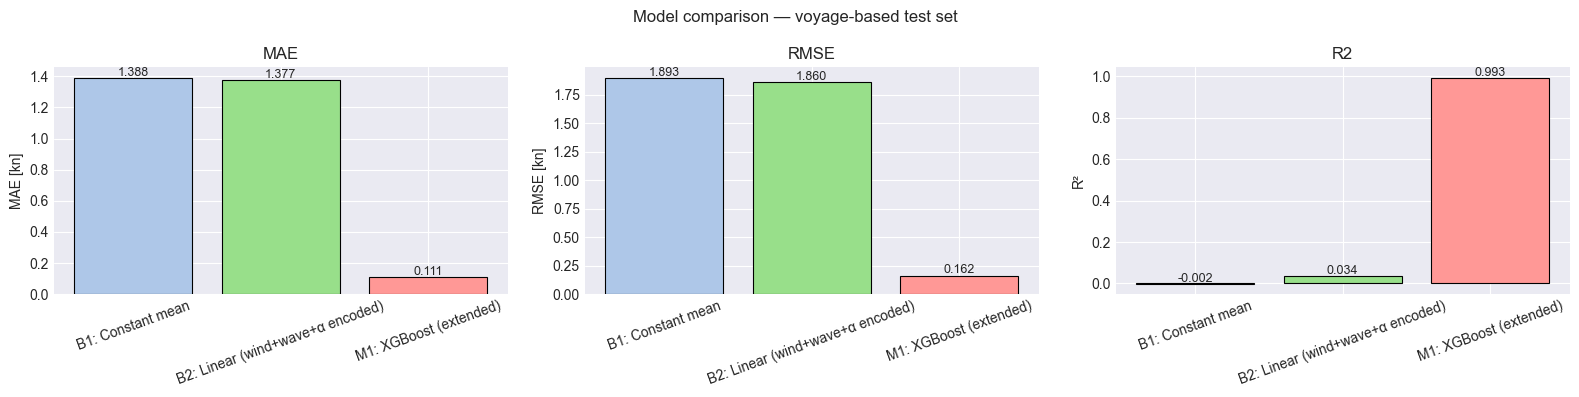

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_names = list(results.keys())
colors = ['#aec7e8', '#98df8a', '#ff9896']

for ax, metric, ylabel in zip(
    axes,
    ['MAE', 'RMSE', 'R2'],
    ['MAE [kn]', 'RMSE [kn]', 'R²']
):
    vals = [results[m][metric] for m in model_names]
    ax.bar(model_names, vals, color=colors, edgecolor='black', linewidth=0.8)
    ax.set_title(metric)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals)*0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Model comparison — voyage-based test set', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Predicted vs Actual (XGBoost)

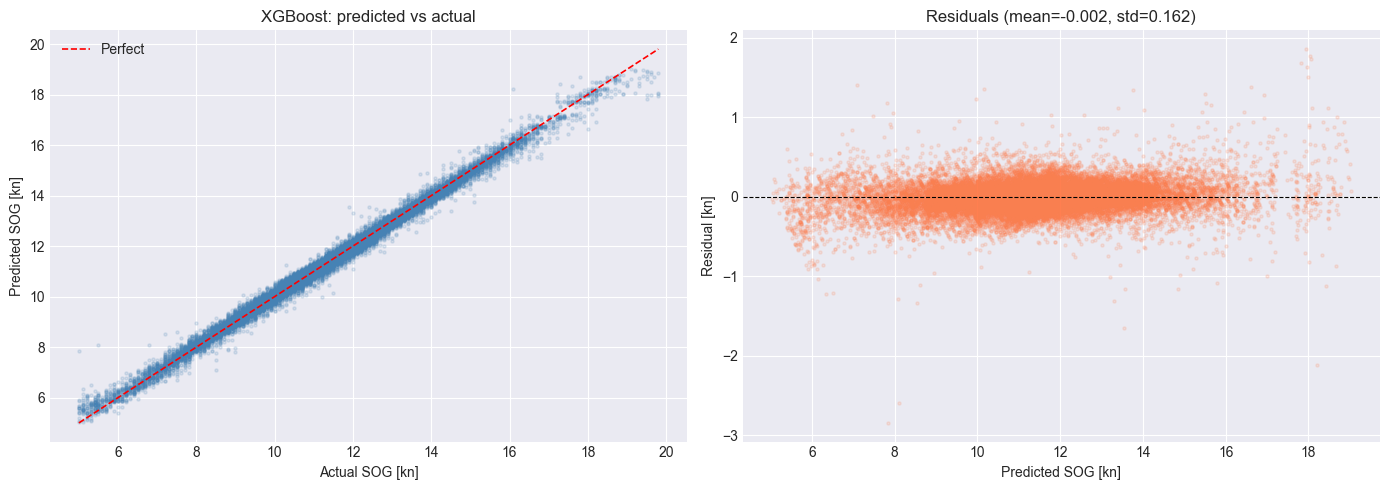

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# predicted vs actual
axes[0].scatter(y_test, y_pred_xgb, alpha=0.15, s=5, color='steelblue')
lims = [min(y_test.min(), y_pred_xgb.min()), max(y_test.max(), y_pred_xgb.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.2, label='Perfect')
axes[0].set_xlabel('Actual SOG [kn]')
axes[0].set_ylabel('Predicted SOG [kn]')
axes[0].set_title('XGBoost: predicted vs actual')
axes[0].legend()

# residuals
residuals = y_test - y_pred_xgb
axes[1].scatter(y_pred_xgb, residuals, alpha=0.15, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Predicted SOG [kn]')
axes[1].set_ylabel('Residual [kn]')
axes[1].set_title(f'Residuals (mean={residuals.mean():.3f}, std={residuals.std():.3f})')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance

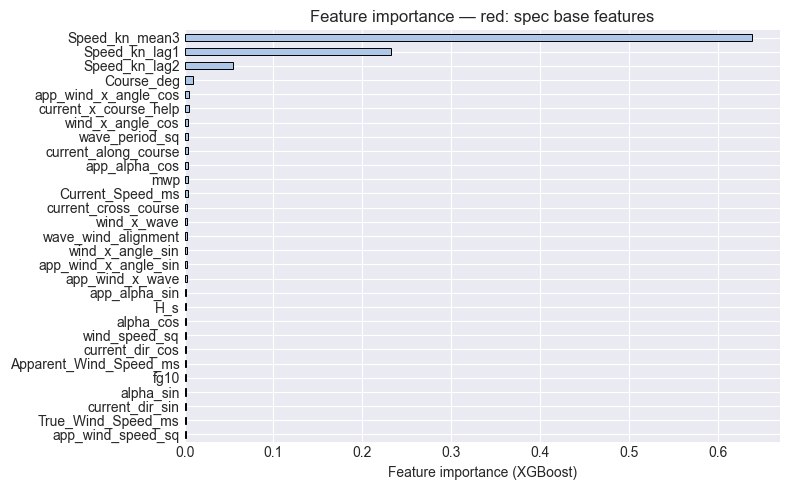


Core spec features (U_wind, H_s, alpha encoded) cumulative importance: 0.007
Alpha (sin+cos) cumulative importance: 0.003


In [22]:
importances = pd.Series(model_xgb.feature_importances_, index=FEATURES_EXT).sort_values(ascending=True)

# Spec core features now use encoded alpha instead of raw alpha_deg
core_spec_features = ['True_Wind_Speed_ms', 'H_s', 'alpha_sin', 'alpha_cos']

fig, ax = plt.subplots(figsize=(8, 5))
colors_imp = ['#ff9896' if f in core_spec_features else '#aec7e8' for f in importances.index]
importances.plot.barh(ax=ax, color=colors_imp, edgecolor='black', linewidth=0.7)
ax.set_xlabel('Feature importance (XGBoost)')
ax.set_title('Feature importance — red: spec base features')
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

core_available = [f for f in core_spec_features if f in importances.index]
core_importance = importances[core_available].sum()
alpha_importance = importances[[f for f in ['alpha_sin', 'alpha_cos'] if f in importances.index]].sum()

print("\nCore spec features (U_wind, H_s, alpha encoded) cumulative importance:",
      f"{core_importance:.3f}")
print("Alpha (sin+cos) cumulative importance:", f"{alpha_importance:.3f}")

## 9. Rotor What-If Scenario

Using the rotor polar diagram (from `feature_engineering.ipynb`), we estimate the expected rotor power contribution for each test observation. Since the training data was collected with rotors operating, we use this as the *with-rotors* baseline. The *without-rotors* counterfactual subtracts the estimated rotor power, converted to a speed equivalent.

**Speed conversion:** A rough approximation at ~12 kn is `ΔV [kn] ≈ P_rotor [kW] / 200`. This assumes a linear thrust-speed relationship around the operating point and is suitable for planning-level scenario comparison.

In [16]:
# rotor polar diagram (same as feature_engineering.ipynb)
WIND_SPEEDS = np.array([4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24])
WIND_ANGLES = np.array([0, 20, 40, 60, 80, 90, 100, 120, 140, 160, 180])
POWER_TABLE = np.array([
    [  0,   3,  10,  14,  16,  14,  12,   7,   3,   1,   0],
    [ -2,   6,  22,  38,  44,  42,  38,  22,   9,   3,   0],
    [ -5,  12,  45,  78,  90,  87,  78,  46,  19,   7,   0],
    [ -8,  20,  75, 128, 148, 144, 130,  76,  32,  11,   0],
    [-12,  30, 110, 186, 215, 210, 188, 110,  46,  16,   0],
    [-16,  42, 152, 256, 297, 290, 260, 152,  64,  22,   0],
    [-21,  56, 200, 335, 390, 380, 340, 199,  83,  29,   0],
    [-27,  72, 254, 425, 496, 484, 433, 254, 106,  37,   0],
    [-33,  90, 315, 526, 614, 599, 537, 314, 131,  46,   0],
    [-40, 110, 382, 638, 745, 727, 651, 381, 159,  55,   0],
    [-48, 132, 456, 762, 890, 868, 778, 455, 190,  66,   0],
])

_interp = RegularGridInterpolator(
    (WIND_SPEEDS, WIND_ANGLES), POWER_TABLE, method='linear',
    bounds_error=False, fill_value=None
)

def rotor_power_kw(wind_ms, alpha_abs):
    ws = np.clip(np.asarray(wind_ms, float), WIND_SPEEDS.min(), WIND_SPEEDS.max())
    wa = np.clip(np.asarray(alpha_abs, float), WIND_ANGLES.min(), WIND_ANGLES.max())
    return _interp(np.column_stack([ws.ravel(), wa.ravel()])).reshape(ws.shape)


KW_PER_KN = 200.0  # rough conversion: 200 kW ≈ 1 kn at operating point

# rotor contribution on test set
p_rotor = rotor_power_kw(
    df_test['True_Wind_Speed_ms'].values,
    df_test['alpha_abs_deg'].values
)

# rotor active: positive power, H_s ≤ 6, wind ≤ 42
active = (p_rotor > 0) & (df_test['H_s'].values <= 6.0) & (df_test['True_Wind_Speed_ms'].values <= 42.0)

delta_v = np.where(active, p_rotor / KW_PER_KN, 0.0)

# with-rotor prediction = XGBoost prediction (trained on data with rotors operating)
# without-rotor counterfactual = subtract the estimated rotor contribution
y_pred_with_rotor    = y_pred_xgb
y_pred_without_rotor = y_pred_xgb - delta_v

print(f"Rotor active: {active.sum():,} / {len(active):,} rows ({active.mean()*100:.1f}%)")
print(f"Mean rotor power when active: {p_rotor[active].mean():.1f} kW")
print(f"Mean delta_SOG when active: {delta_v[active].mean():.3f} kn")
print(f"Overall mean delta_SOG: {delta_v.mean():.3f} kn")

Rotor active: 35,077 / 35,758 rows (98.1%)
Mean rotor power when active: 41.2 kW
Mean delta_SOG when active: 0.206 kn
Overall mean delta_SOG: 0.202 kn


In [17]:
# per-voyage rotor benefit
df_test_copy = df_test.copy()
df_test_copy['pred_with_rotor'] = y_pred_with_rotor
df_test_copy['pred_without_rotor'] = y_pred_without_rotor
df_test_copy['delta_v'] = delta_v
df_test_copy['rotor_active'] = active.astype(int)

voyage_summary = df_test_copy.groupby('Voyage_ID').agg(
    n_points = ('Speed_kn', 'count'),
    mean_sog_actual = ('Speed_kn', 'mean'),
    mean_sog_pred = ('pred_with_rotor', 'mean'),
    mean_sog_no_rot = ('pred_without_rotor', 'mean'),
    rotor_active_pct= ('rotor_active', 'mean'),
    mean_delta_v = ('delta_v', 'mean'),
).round(3)

voyage_summary['delta_v_kn'] = (voyage_summary['mean_sog_pred'] - voyage_summary['mean_sog_no_rot']).round(3)

print("Per-voyage rotor scenario summary (test set):")
print(voyage_summary.sort_values('mean_delta_v', ascending=False).head(10).to_string())

Per-voyage rotor scenario summary (test set):
           n_points  mean_sog_actual  mean_sog_pred  mean_sog_no_rot  rotor_active_pct  mean_delta_v  delta_v_kn
Voyage_ID                                                                                                       
501             142           12.977         12.950           11.760             1.000         1.189       1.190
488             125           14.130         14.078           13.303             1.000         0.776       0.775
456             511           11.501         11.522           10.779             1.000         0.743       0.743
520             328           11.840         11.849           11.170             0.988         0.679       0.679
474             495           11.784         11.792           11.214             0.998         0.578       0.578
525             951           11.829         11.826           11.292             0.999         0.534       0.534
492             125           13.522         13.52

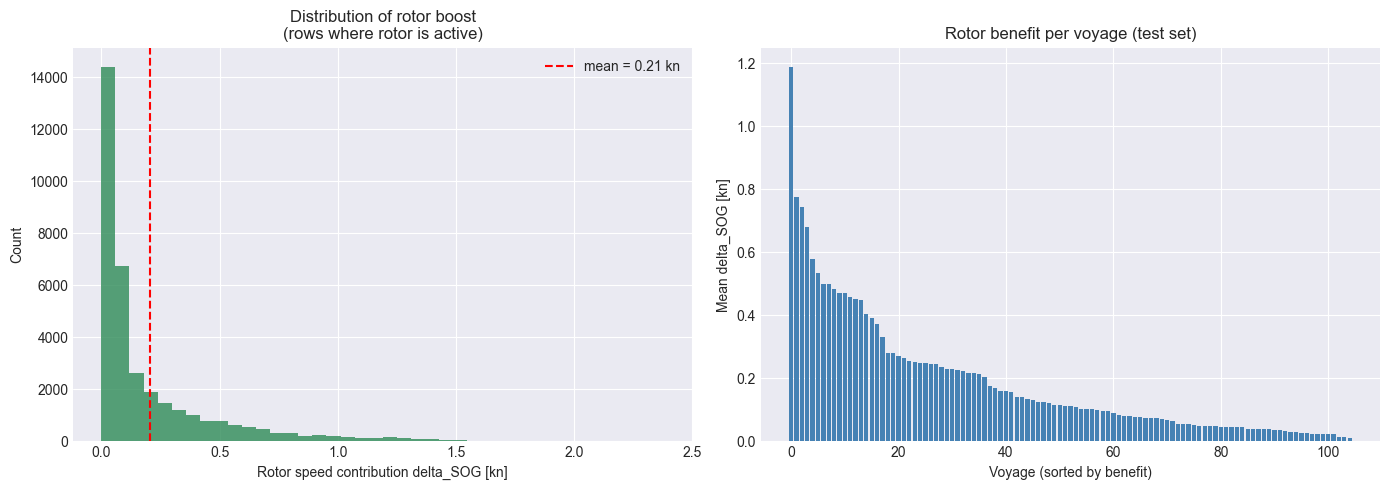

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of ΔSOG
axes[0].hist(delta_v[active], bins=40, color='seagreen', edgecolor='none', alpha=0.8)
axes[0].axvline(delta_v[active].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'mean = {delta_v[active].mean():.2f} kn')
axes[0].set_xlabel('Rotor speed contribution delta_SOG [kn]')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of rotor boost\n(rows where rotor is active)')
axes[0].legend()

# Per-voyage mean delta_SOG
dvs = voyage_summary['mean_delta_v'].sort_values(ascending=False)
axes[1].bar(range(len(dvs)), dvs.values, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Voyage (sorted by benefit)')
axes[1].set_ylabel('Mean delta_SOG [kn]')
axes[1].set_title('Rotor benefit per voyage (test set)')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'rotor_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Weather Window Analysis

**Definition (spec):** A weather window is a contiguous time interval where:
- Predicted SOG ≥ threshold (e.g. 10 kn)
- H_s ≤ threshold (e.g. 3 m)

We compare window counts and lengths between the baseline (no rotor) and with-rotor scenarios.

In [19]:
SOG_THRESHOLD = 10.0   # minimum speed [kn]
HS_THRESHOLD  = 3.0    # maximum wave height [m]

def count_windows(sog_series, hs_series, sog_min, hs_max):
    """Count contiguous windows meeting both conditions."""
    in_window = (sog_series >= sog_min) & (hs_series <= hs_max)
    # Count transitions False→True
    starts = np.sum(~in_window.values[:-1] & in_window.values[1:])
    if in_window.values[0]:
        starts += 1
    total_points = in_window.sum()
    return int(starts), int(total_points)


hs_test = df_test['H_s'].values

n_win_base, pts_base = count_windows(
    pd.Series(y_pred_without_rotor), pd.Series(hs_test), SOG_THRESHOLD, HS_THRESHOLD)
n_win_rot,  pts_rot  = count_windows(
    pd.Series(y_pred_with_rotor),    pd.Series(hs_test), SOG_THRESHOLD, HS_THRESHOLD)

total = len(y_pred_xgb)
print(f"Weather window definition: SOG ≥ {SOG_THRESHOLD} kn  AND  H_s ≤ {HS_THRESHOLD} m")
print(f"")
print(f"{'Scenario':<25} {'Windows':>10} {'Points in window':>18} {'Coverage':>10}")
print("-" * 65)
print(f"{'Without rotor':<25} {n_win_base:>10} {pts_base:>18,} {pts_base/total*100:>9.1f}%")
print(f"{'With rotor':<25} {n_win_rot:>10} {pts_rot:>18,} {pts_rot/total*100:>9.1f}%")
print(f"{'Delta':<25} {n_win_rot-n_win_base:>+10} {pts_rot-pts_base:>+18,} {(pts_rot-pts_base)/total*100:>+9.1f}%")

Weather window definition: SOG ≥ 10.0 kn  AND  H_s ≤ 3.0 m

Scenario                     Windows   Points in window   Coverage
-----------------------------------------------------------------
Without rotor                    754             27,155      75.9%
With rotor                       711             27,734      77.6%
Delta                            -43               +579      +1.6%


## 11. Summary

In [20]:
print("=" * 70)
print("MARITIME SPEED PREDICTION — SUMMARY")
print("=" * 70)
print(f"Target: Speed_kn (SOG)")
print(f"Train: {len(train_voyages)} voyages ({len(df_train):,} rows)")
print(f"Test: {len(test_voyages)} voyages ({len(df_test):,} rows) [chronological split]")
print()
print(f"{'Model':<30} {'MAE [kn]':>10} {'RMSE [kn]':>10} {'R²':>8}")
print("-" * 60)
for name, m in results.items():
    print(f"{name:<30} {m['MAE']:>10.3f} {m['RMSE']:>10.3f} {m['R2']:>8.3f}")
print()
print(f"Rotor active (test set): {active.mean()*100:.1f}% of observations")
print(f"Mean rotor delta_SOG (active): {delta_v[active].mean():.3f} kn")
print(f"Weather window coverage: {pts_base/total*100:.1f}% → {pts_rot/total*100:.1f}% (with rotors)")
print("=" * 70)

MARITIME SPEED PREDICTION — SUMMARY
Target: Speed_kn (SOG)
Train: 422 voyages (88,346 rows)
Test: 106 voyages (35,758 rows) [chronological split]

Model                            MAE [kn]  RMSE [kn]       R²
------------------------------------------------------------
B1: Constant mean                   1.388      1.893   -0.002
B2: Linear (wind+wave+α encoded)      1.377      1.860    0.034
M1: XGBoost (extended)              0.111      0.162    0.993

Rotor active (test set): 98.1% of observations
Mean rotor delta_SOG (active): 0.206 kn
Weather window coverage: 75.9% → 77.6% (with rotors)


## 12.Trajectory visualization

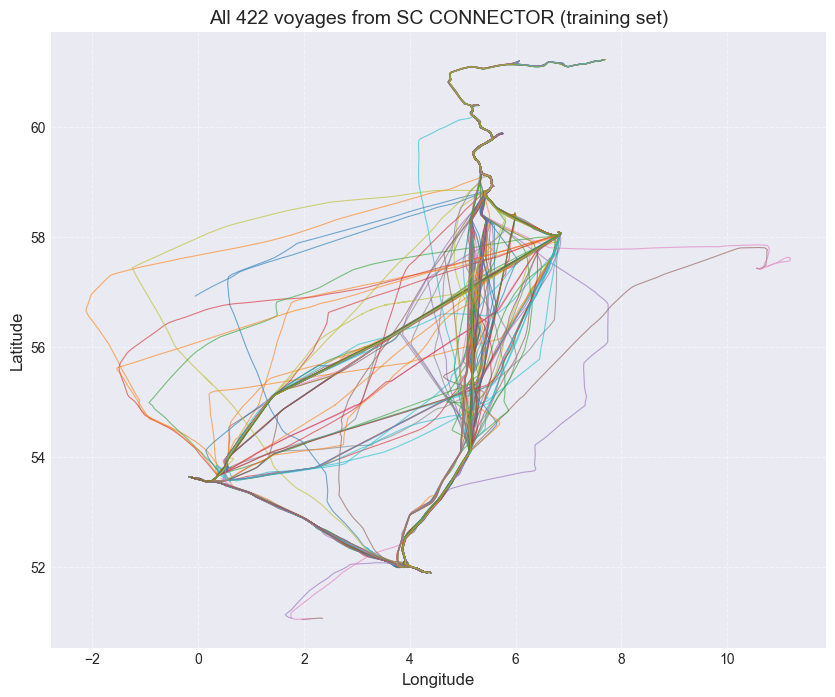

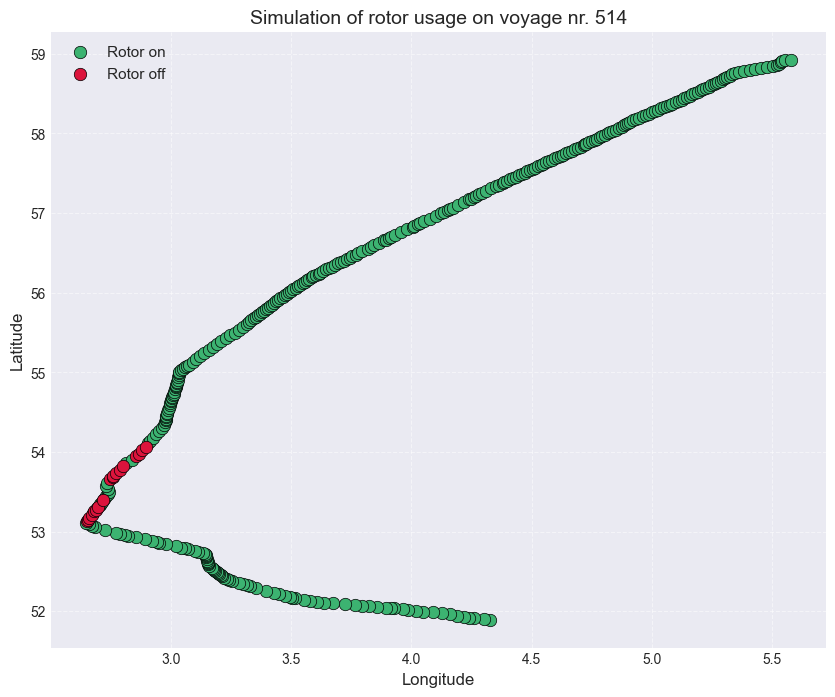

In [21]:
# map 1 - are trips overlapping? 
plt.figure(figsize=(10, 8))
# all trips to see repetability (from train set)
for v_id in df_train['Voyage_ID'].unique()[:422]:
    v_data = df_train[df_train['Voyage_ID'] == v_id]
    plt.plot(v_data['Lon'], v_data['Lat'], linewidth=0.8, alpha=0.6)

plt.title("All 422 voyages from SC CONNECTOR (training set)", fontsize=14)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(RESULTS_PATH + 'all_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()


# map 2 - when the rotor is on? 
voyage = 514
v_data = df_test_copy[df_test_copy['Voyage_ID'] == voyage]

plt.figure(figsize=(10, 8))

# whole trajectory
plt.plot(v_data['Lon'], v_data['Lat'], color='gray', linestyle='--', linewidth=1.5, zorder=1)

# green points = rotor on
rotor_on = v_data[v_data['rotor_active'] == 1]
plt.scatter(rotor_on['Lon'], rotor_on['Lat'], c='mediumseagreen', s=80, edgecolor='black', linewidth=0.5, label='Rotor on', zorder=2)

# red points = rotor off
rotor_off = v_data[v_data['rotor_active'] == 0]
if not rotor_off.empty:
    plt.scatter(rotor_off['Lon'], rotor_off['Lat'], c='crimson', s=80, edgecolor='black', linewidth=0.5, label='Rotor off', zorder=3)

plt.title(f"Simulation of rotor usage on voyage nr. {voyage}", fontsize=14)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(RESULTS_PATH + f'rotor_voyage_{voyage}.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Compact diagnostics for reporting
print('=== COMPACT SUMMARY ===')
print(f"Rows: train={len(df_train):,}, test={len(df_test):,}")
print(f"Voyages: train={len(train_voyages)}, test={len(test_voyages)}")
print(f"No temporal leakage: {df_train['Time'].max() < df_test['Time'].min()}")
print('')

print('Model metrics:')
for name, m in results.items():
    print(f"- {name}: MAE={m['MAE']:.3f}, RMSE={m['RMSE']:.3f}, R2={m['R2']:.3f}, within±1kn={m['within_1kn']:.1f}%")
print('')

if 'M1: XGBoost (extended)' in results and 'B2: Linear (wind+wave+α encoded)' in results:
    d_mae = results['B2: Linear (wind+wave+α encoded)']['MAE'] - results['M1: XGBoost (extended)']['MAE']
    d_rmse = results['B2: Linear (wind+wave+α encoded)']['RMSE'] - results['M1: XGBoost (extended)']['RMSE']
    print(f"XGBoost gain vs B2: ΔMAE={d_mae:+.3f}, ΔRMSE={d_rmse:+.3f}")
print('')

print('Rotor scenario:')
print(f"- Rotor active share: {active.mean()*100:.1f}%")
print(f"- Mean rotor power (active): {p_rotor[active].mean():.1f} kW")
print(f"- Mean delta_SOG (active): {delta_v[active].mean():.3f} kn")
print(f"- Mean delta_SOG (overall): {delta_v.mean():.3f} kn")
print('')

print('Weather windows (SOG>=10, Hs<=3):')
print(f"- Without rotor: windows={n_win_base}, points={pts_base:,}, coverage={pts_base/total*100:.1f}%")
print(f"- With rotor:    windows={n_win_rot}, points={pts_rot:,}, coverage={pts_rot/total*100:.1f}%")
print(f"- Delta:         windows={n_win_rot-n_win_base:+d}, points={pts_rot-pts_base:+,}, coverage={(pts_rot-pts_base)/total*100:+.1f}%")
print('')

print('Top 10 feature importances:')
print(importances.sort_values(ascending=False).head(10).to_string())
print('')
print(f"Core encoded spec importance (U_wind, H_s, alpha_sin, alpha_cos): {core_importance:.3f}")
print(f"Alpha encoded importance (sin+cos): {alpha_importance:.3f}")

=== COMPACT SUMMARY ===
Rows: train=88,346, test=35,758
Voyages: train=422, test=106
No temporal leakage: True

Model metrics:
- B1: Constant mean: MAE=1.388, RMSE=1.893, R2=-0.002, within±1kn=49.3%
- B2: Linear (wind+wave+α encoded): MAE=1.377, RMSE=1.860, R2=0.034, within±1kn=49.5%
- M1: XGBoost (extended): MAE=0.111, RMSE=0.162, R2=0.993, within±1kn=99.9%

XGBoost gain vs B2: ΔMAE=+1.266, ΔRMSE=+1.698

Rotor scenario:
- Rotor active share: 98.1%
- Mean rotor power (active): 41.2 kW
- Mean delta_SOG (active): 0.206 kn
- Mean delta_SOG (overall): 0.202 kn

Weather windows (SOG>=10, Hs<=3):
- Without rotor: windows=754, points=27,155, coverage=75.9%
- With rotor:    windows=711, points=27,734, coverage=77.6%
- Delta:         windows=-43, points=+579, coverage=+1.6%

Top 10 feature importances:
Speed_kn_mean3           0.638342
Speed_kn_lag1            0.232837
Speed_kn_lag2            0.054942
Course_deg               0.009340
app_wind_x_angle_cos     0.005102
current_x_course_help    